In [98]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

In [99]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH    = 72
FIGSIZE        = (500 / PT_PER_INCH, 320 / PT_PER_INCH)   # big plots
FIGSIZE_INSET  = (250 / PT_PER_INCH, 205 / PT_PER_INCH)   # insets

font_scale        = 1.5
label_fs          = int(12 * font_scale)
legend_fs         = int(9  * font_scale)
tick_labelsize    = int(10 * font_scale)
scaled_markersize = int(0.8  * font_scale)

# Distinct colours (blue, orange, pink, green) — one per nqpa
line_colors = ["#1f77b4", "#d78e20", "#c459a1", "#498c41"]
# Markers for amplified curves (nqpa >= 1)
markers = ["o", "s", "D"]


## Hamiltonian Simulation with Trotterization

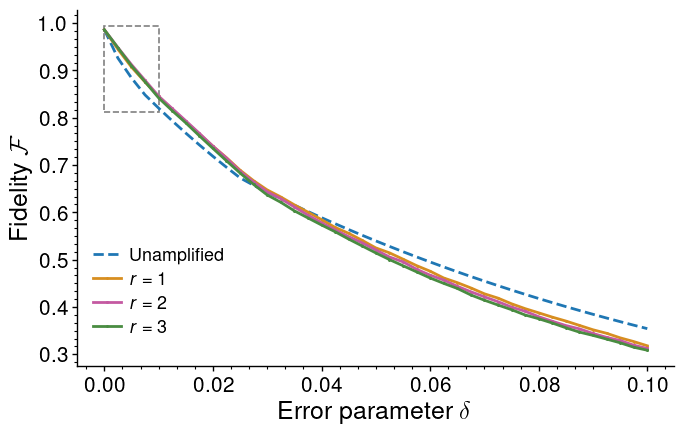

In [100]:
fig, ax = plt.subplots(figsize=FIGSIZE)

files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        grouped.setdefault(int(match.group(1)), []).append((int(match.group(2)), file))
    else:
        print(f"Skipping {file} — pattern not matched")

nqpas = sorted(grouped.keys())

# Build fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best = {}
    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [c for c in df.columns if c.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue
        for eps, fid in zip(df["epsilon"], df[qpa_col[0]]):
            eps_to_best[eps] = max(eps_to_best.get(eps, -1), fid)
    eps_s = sorted(eps_to_best)
    fidelity_curves[nqpa] = (eps_s, [eps_to_best[e] for e in eps_s])

# nqpa=0: dashed, no marker; nqpa>=1: solid + marker
for idx, nqpa in enumerate(nqpas):
    color = line_colors[idx % len(line_colors)]
    eps_s, fids_s = fidelity_curves[nqpa]
    if nqpa == 0:
        ax.plot(eps_s, fids_s, color=color, linestyle="--",
                linewidth=2, label="Unamplified")
    else:
        marker = markers[(idx - 1) % len(markers)]
        ax.plot(eps_s, fids_s, color=color, marker=marker,
                markersize=scaled_markersize, linewidth=2, label=fr"$r={nqpa}$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)
ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)
ax.legend(
    loc="lower left",
    fontsize=legend_fs,
    frameon=False,
    borderaxespad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.4,
    borderpad=0.4,
    ncol=1,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.0, 0.04),
)
# Gray dashed box: y-extent covers all curves within x in [0, 0.01]
_ys = [f for _nq, (_es, _fs) in fidelity_curves.items()
         for _e, f in zip(_es, _fs) if _e <= 0.01]
_ylo_box = min(_ys)
_yhi_box = max(_ys)
_pad = 0.05 * (_yhi_box - _ylo_box)
ax.add_patch(mpl.patches.Rectangle(
    (0.0, _ylo_box - _pad), 0.01, (_yhi_box - _ylo_box) + 2 * _pad,
    linewidth=1.2, edgecolor="gray", facecolor="none",
    linestyle="--", zorder=0))
fig.tight_layout()
fig.savefig('aer_trotter_estimation/big.svg', bbox_inches='tight', format='svg')
plt.show()
plt.close()


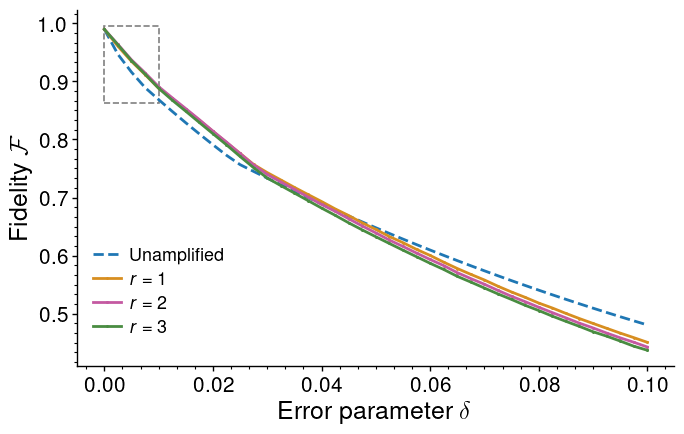

In [101]:
fig, ax = plt.subplots(figsize=FIGSIZE)

files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        grouped.setdefault(int(match.group(1)), []).append((int(match.group(2)), file))
    else:
        print(f"Skipping {file} — pattern not matched")

nqpas = sorted(grouped.keys())

# Build fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best = {}
    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [c for c in df.columns if c.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue
        for eps, fid in zip(df["epsilon"], df[qpa_col[0]]):
            eps_to_best[eps] = max(eps_to_best.get(eps, -1), fid)
    eps_s = sorted(eps_to_best)
    fidelity_curves[nqpa] = (eps_s, [eps_to_best[e] for e in eps_s])

# nqpa=0: dashed, no marker; nqpa>=1: solid + marker
for idx, nqpa in enumerate(nqpas):
    color = line_colors[idx % len(line_colors)]
    eps_s, fids_s = fidelity_curves[nqpa]
    if nqpa == 0:
        ax.plot(eps_s, fids_s, color=color, linestyle="--",
                linewidth=2, label="Unamplified")
    else:
        marker = markers[(idx - 1) % len(markers)]
        ax.plot(eps_s, fids_s, color=color, marker=marker,
                markersize=scaled_markersize, linewidth=2, label=fr"$r={nqpa}$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)
ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"Fidelity $\mathcal{F}$", fontsize=label_fs)
ax.legend(
    loc="lower left",
    fontsize=legend_fs,
    frameon=False,
    borderaxespad=0.5,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.4,
    borderpad=0.4,
    ncol=1,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.0, 0.04),
)
# Gray dashed box: y-extent covers all curves within x in [0, 0.01]
_ys = [f for _nq, (_es, _fs) in fidelity_curves.items()
         for _e, f in zip(_es, _fs) if _e <= 0.01]
_ylo_box = min(_ys)
_yhi_box = max(_ys)
_pad = 0.05 * (_yhi_box - _ylo_box)
ax.add_patch(mpl.patches.Rectangle(
    (0.0, _ylo_box - _pad), 0.01, (_yhi_box - _ylo_box) + 2 * _pad,
    linewidth=1.2, edgecolor="gray", facecolor="none",
    linestyle="--", zorder=0))
fig.tight_layout()
fig.savefig('aer_trotter_estimation/big_k=3.svg', bbox_inches='tight', format='svg')
plt.show()
plt.close()


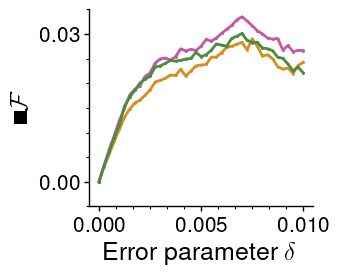

In [102]:
fig, ax = plt.subplots(figsize=FIGSIZE_INSET)

files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        grouped.setdefault(int(match.group(1)), []).append((int(match.group(2)), file))
    else:
        print(f"Skipping {file} — pattern not matched")

nqpas = sorted(grouped.keys())

# Build fidelity curves and nqpa=0 baseline
base_fid_dict  = {}
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best = {}
    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [c for c in df.columns if c.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue
        for eps, fid in zip(df["epsilon"], df[qpa_col[0]]):
            eps_to_best[eps] = max(eps_to_best.get(eps, -1), fid)
    eps_s = sorted(eps_to_best)
    fidelity_curves[nqpa] = (eps_s, [eps_to_best[e] for e in eps_s])
    if nqpa == 0:
        base_fid_dict = dict(zip(eps_s, [eps_to_best[e] for e in eps_s]))

# Plot delta-F for amplified curves; same colour/marker indexing as big plot
for idx, nqpa in enumerate(nqpas):
    if nqpa == 0:
        continue
    color  = line_colors[idx % len(line_colors)]
    marker = markers[(idx - 1) % len(markers)]
    eps, fids = fidelity_curves[nqpa]
    delta = [f - base_fid_dict.get(e, 0) for f, e in zip(fids, eps)]
    ax.plot(eps, delta, color=color, marker=marker,
            markersize=scaled_markersize, linewidth=2, label=fr"$r={nqpa}$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)
ax.set_xticks([0.0, 0.005, 0.01])
ax.set_yticks([-0.03, 0.00, 0.03])
ax.set_ylim(-0.005, 0.035)
ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"$\Delta\mathcal{F}$", fontsize=label_fs)
fig.tight_layout()
fig.savefig('aer_trotter_estimation/inset.svg', bbox_inches='tight', format='svg')
plt.show()


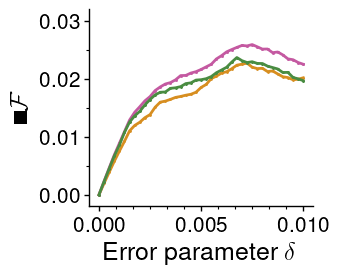

In [103]:
fig, ax = plt.subplots(figsize=FIGSIZE_INSET)

files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        grouped.setdefault(int(match.group(1)), []).append((int(match.group(2)), file))
    else:
        print(f"Skipping {file} — pattern not matched")

nqpas = sorted(grouped.keys())

# Build fidelity curves and nqpa=0 baseline
base_fid_dict  = {}
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best = {}
    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [c for c in df.columns if c.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue
        for eps, fid in zip(df["epsilon"], df[qpa_col[0]]):
            eps_to_best[eps] = max(eps_to_best.get(eps, -1), fid)
    eps_s = sorted(eps_to_best)
    fidelity_curves[nqpa] = (eps_s, [eps_to_best[e] for e in eps_s])
    if nqpa == 0:
        base_fid_dict = dict(zip(eps_s, [eps_to_best[e] for e in eps_s]))

# Plot delta-F for amplified curves; same colour/marker indexing as big plot
for idx, nqpa in enumerate(nqpas):
    if nqpa == 0:
        continue
    color  = line_colors[idx % len(line_colors)]
    marker = markers[(idx - 1) % len(markers)]
    eps, fids = fidelity_curves[nqpa]
    delta = [f - base_fid_dict.get(e, 0) for f, e in zip(fids, eps)]
    ax.plot(eps, delta, color=color, marker=marker,
            markersize=scaled_markersize, linewidth=2, label=fr"$r={nqpa}$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_minor_locator(AutoMinorLocator(6))
ax.yaxis.set_minor_locator(AutoMinorLocator(6))
ax.tick_params(which="major", direction="out", width=1, labelsize=tick_labelsize)
ax.tick_params(which="minor", direction="out", width=0.8)
ax.grid(False)
ax.set_xticks([0.0, 0.005, 0.01])
ax.set_yticks([-0.03, 0.00, 0.01, 0.02, 0.03])
ax.set_ylim(-0.002, 0.032)
ax.set_xlabel(r"Error parameter $\delta$", fontsize=label_fs)
ax.set_ylabel(r"$\Delta\mathcal{F}$", fontsize=label_fs)
fig.tight_layout()
fig.savefig('aer_trotter_estimation/insetk=3.svg', bbox_inches='tight', format='svg')
plt.show()


## Global Depolarization